In [1]:
import numpy as np
import pandas as pd
import random

In [2]:
import torch
from Bio import SeqIO

In [3]:
def one_hot_encode_sequence(sequence_obj):
    # Convert pyfaidx.Sequence object to string
    sequence = str(sequence_obj).upper()
    
    # Define the mapping from bases to integers
    base_to_int = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    valid_bases = list(base_to_int.keys())

    # Step 1: Convert sequence to integer encoding with random base for 'N'
    encoded_indices = []
    for base in sequence:
        if base in base_to_int:
            encoded_indices.append(base_to_int[base])
        else:
            random_base = random.choice(valid_bases)
            encoded_indices.append(base_to_int[random_base])

    # Step 2: One-hot encode the sequence
    encoded_sequence = np.array(encoded_indices)
    one_hot_encoded = np.zeros((4, len(encoded_sequence)), dtype=np.float32)
    one_hot_encoded[encoded_sequence, np.arange(len(encoded_sequence))] = 1

    return one_hot_encoded

In [4]:
def load_fasta_as_batch_ohe(fasta_path):
    """
    Load DNA sequences from a FASTA file and return a [N, 4, L] tensor of one-hot encoded sequences.
    """
    ohe_list = []
    for record in SeqIO.parse(fasta_path, "fasta"):
        seq = str(record.seq).upper()
        ohe = one_hot_encode_sequence(seq)  # (4, L)
        ohe_list.append(ohe)

    # Check all sequences have same length
    lengths = [x.shape[1] for x in ohe_list]
    assert len(set(lengths)) == 1, f"Sequences have inconsistent lengths: {lengths}"

    ohe_batch = np.stack(ohe_list, axis=0)  # shape: (N, 4, L)
    return torch.from_numpy(ohe_batch)

In [7]:
import sys
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

# from model import SeqNN
from model_v2_compatible import SeqNN

In [8]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [9]:
model = SeqNN()
model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_finetuned_correctly.pt", map_location=device))
model.eval()

/tmp/SLURM_795052/ipykernel_3133750/2744654124.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_f

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=2, stride=2, paddi

In [5]:
fasta_path = "/scratch1/smaruj/background_generation/background_sequences_scd30_totvar1500.fasta"

In [10]:
batch_tensor = load_fasta_as_batch_ohe(fasta_path)  # shape: [10, 4, 1310720]
batch_tensor = batch_tensor.to(device)


In [11]:
def local_std_metric_batch(preds, window=32, stride=32):
    """
    Compute mean local standard deviation per map in a batch of shape [B, H, W],
    ignoring NaNs.
    Returns: array of shape [B], one std score per map.
    """
    B, H, W = preds.shape
    results = []

    for b in range(B):
        vals = []
        for i in range(0, H - window + 1, stride):
            for j in range(0, W - window + 1, stride):
                patch = preds[b, i:i+window, j:j+window]
                std = np.nanstd(patch)
                vals.append(std)
        results.append(np.nanmean(vals))

    return np.array(results)

def total_variation_batch(preds):
    """
    Compute total variation per map in a batch of shape [B, H, W],
    ignoring NaNs.
    Returns: array of shape [B]
    """
    B, H, W = preds.shape
    results = []

    for b in range(B):
        pred = preds[b]
        dx = pred[:, 1:] - pred[:, :-1]
        dy = pred[1:, :] - pred[:-1, :]

        # Flatten and remove NaNs
        dx = dx[~np.isnan(dx)]
        dy = dy[~np.isnan(dy)]

        total_var = np.sum(np.abs(dx)) + np.sum(np.abs(dy))
        results.append(total_var)

    return np.array(results)

In [12]:
import numpy as np
import torch

def set_diag(matrix, value, k):
    """Set diagonal `k` of a matrix to `value`."""
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value

def from_upper_triu_batch(batch_vectors, matrix_len=512, num_diags=2):
    """Convert a batch of upper-triangular vectors into symmetric matrices with np.nan on diagonals."""
    if isinstance(batch_vectors, torch.Tensor):
        batch_vectors = batch_vectors.detach().cpu().numpy()

    batch_size = len(batch_vectors)
    matrices = np.zeros((batch_size, matrix_len, matrix_len), dtype=np.float32)

    triu_indices = np.triu_indices(matrix_len, num_diags)

    for i in range(batch_size):
        matrices[i][triu_indices] = batch_vectors[i][0,:]
        # Mirror to lower triangle
        matrices[i] = matrices[i] + matrices[i].T

        # Set diagonals to np.nan
        for k in range(-num_diags + 1, num_diags):
            set_diag(matrices[i], np.nan, k)

    return matrices  # shape: [B, 512, 512]

In [13]:
scd_values = []
local_sd_values = []
total_var_values = []

preds_all = []

model.eval()
with torch.no_grad():
        preds = model(batch_tensor).cpu()
        preds_all.extend(preds)
        
        # Compute SCD
        scd_batch = torch.sqrt((preds ** 2).sum(dim=(1, 2)))  # [B]
        scd_values.extend(scd_batch.numpy())
        
        # Decode full 2D maps
        maps = from_upper_triu_batch(preds)  # shape [B, H, W]
        # maps_np = maps.numpy()

        # Compute per-sample metrics
        local_std_batch = local_std_metric_batch(maps)      # shape [B]
        total_var_batch = total_variation_batch(maps)       # shape [B]

        local_sd_values.extend(local_std_batch)
        total_var_values.extend(total_var_batch)

In [15]:
preds_all = torch.cat(preds_all, dim=0)

In [18]:
# Helper function to set diagonal elements to a specific value
def set_diag(matrix, value, k):
    # Explicitly set the diagonal to 'value' (in this case, np.nan) for each k
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value

def from_upper_triu(vector_repr, matrix_len, num_diags):
    # Ensure vector_repr is a NumPy array (if it's a PyTorch tensor, convert it)
    if isinstance(vector_repr, torch.Tensor):
        vector_repr = vector_repr.detach().flatten().cpu().numpy()  # Flatten and convert to NumPy array

    # Initialize a zero matrix of shape (matrix_len, matrix_len)
    z = np.zeros((matrix_len, matrix_len))

    # Get the indices for the upper triangular matrix
    triu_tup = np.triu_indices(matrix_len, num_diags)

    # Assign the values from the vector_repr to the upper triangular part of the matrix
    z[triu_tup] = vector_repr

    # Set the diagonals specified by num_diags to np.nan
    for i in range(-num_diags + 1, num_diags):
        set_diag(z, np.nan, i)

    # Ensure the matrix is symmetric
    return z + z.T

In [19]:
import matplotlib.pyplot as plt

Background 0
SCD = 29.99156951904297, local SD = 0.012497415766119957, total var = 1034.05908203125


<Figure size 500x500 with 0 Axes>

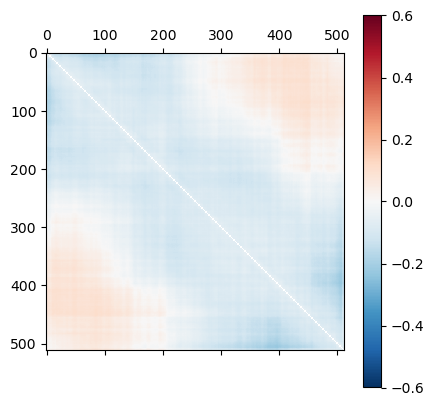

Background 1
SCD = 29.254043579101562, local SD = 0.01473025232553482, total var = 1232.513671875


<Figure size 500x500 with 0 Axes>

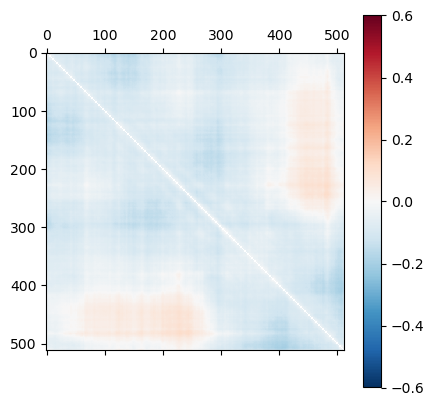

Background 2
SCD = 29.58880043029785, local SD = 0.018955538049340248, total var = 1440.9591064453125


<Figure size 500x500 with 0 Axes>

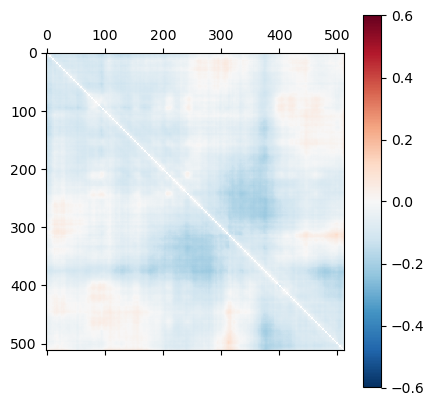

Background 3
SCD = 29.068023681640625, local SD = 0.014505591243505478, total var = 1434.367919921875


<Figure size 500x500 with 0 Axes>

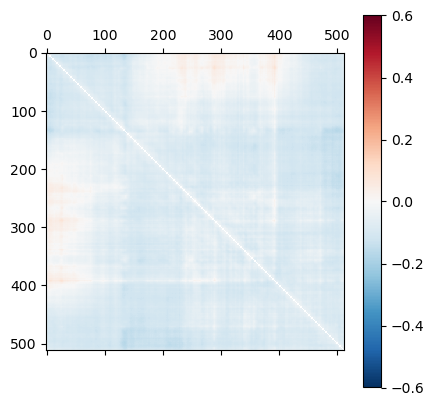

Background 4
SCD = 28.95273208618164, local SD = 0.009826972149312496, total var = 962.7301025390625


<Figure size 500x500 with 0 Axes>

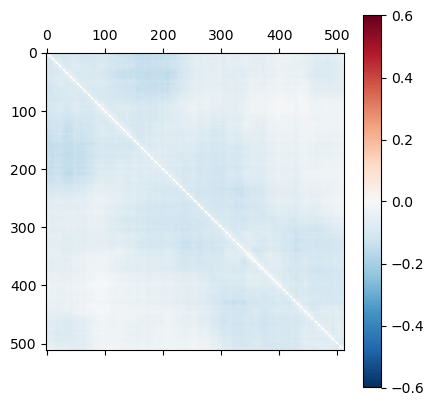

Background 5
SCD = 28.35838508605957, local SD = 0.012685976922512054, total var = 1071.5533447265625


<Figure size 500x500 with 0 Axes>

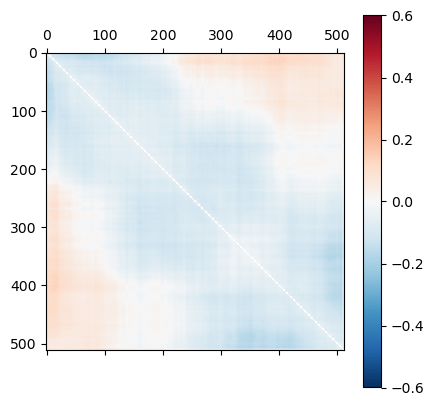

Background 6
SCD = 29.410688400268555, local SD = 0.01757223531603813, total var = 1357.982666015625


<Figure size 500x500 with 0 Axes>

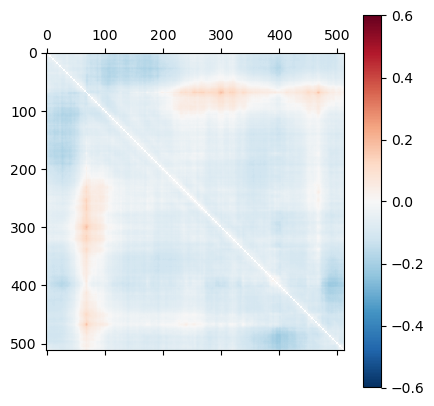

Background 7
SCD = 29.80589485168457, local SD = 0.013629845343530178, total var = 1154.2880859375


<Figure size 500x500 with 0 Axes>

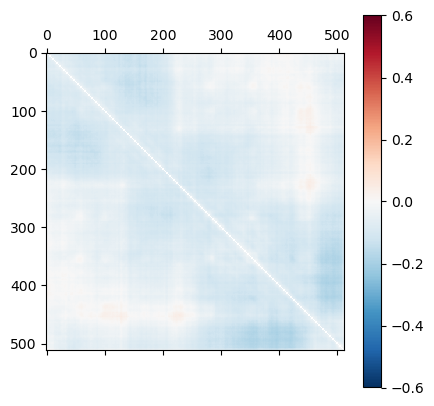

Background 8
SCD = 28.770952224731445, local SD = 0.014432087540626526, total var = 1171.763671875


<Figure size 500x500 with 0 Axes>

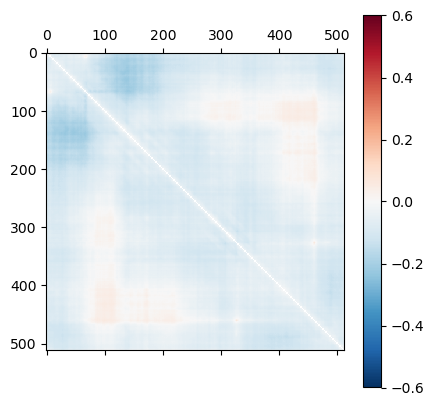

Background 9
SCD = 29.97129249572754, local SD = 0.012508207932114601, total var = 1068.541748046875


<Figure size 500x500 with 0 Axes>

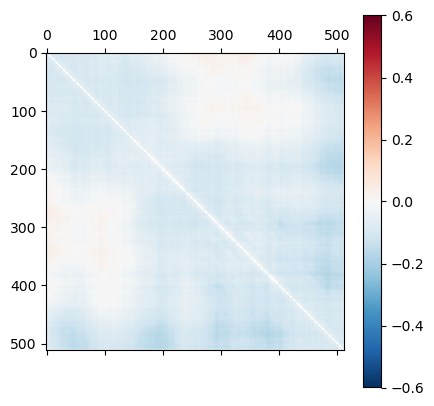

In [20]:
for i in range(10):
    print("Background", i)
    print(f"SCD = {scd_values[i]}, local SD = {local_sd_values[i]}, total var = {total_var_values[i]}")
    matrix = from_upper_triu(preds_all[i,:], matrix_len=512, num_diags=2)
    
    plt.figure(figsize=(5, 5))
    plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    plt.colorbar()
    plt.show()